# **Directed percolation in Rust-Python**

Demo simulation of directed percolation on a 3d lattice.

<hr>

## Preliminaries

In [1]:
from essentials import *
dprs.__version__

'2026.4.21'

<hr>

## Parameters

In [2]:
n_xyz = 300
class Parameters:
    growth_model = GrowthModel.DomanyKinzel
    growth_scheme = GrowthScheme.Simple
    dim = Dimension.D3
    n_x: int = n_xyz
    n_y: int = n_xyz
    n_z: int = n_xyz
    p_1: float = 0.0482745
    p_2: float = 0
    p_conj: float = 0
    p_nbr: float = 0.5
    p_diag: float = 0.5
    u_x: float = 0.0
    n_iterations: int = 1000
    sample_period: int  = 0
    initial_condition = InitialCondition.Randomized
    # initial_condition = InitialCondition.CentralCell
    p_initial: float = 0.99
    random_seed: int = 1
    topology_x = Topology.Periodic
    topology_y = Topology.Periodic
    topology_z = Topology.Periodic
    bcs_x = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_y = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_z = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bc_values_x = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_y = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_z = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    do_edge_buffering: bool = True
    processing = Processing.Parallel
    n_threads: int = 16
parameters = Parameters()
# Just in case we forget to update sample_period to match n_iterations
if parameters.sample_period > parameters.n_iterations:
    parameters.sample_period = parameters.n_iterations

In [3]:
sim.print(parameters)

Growth model:  DomanyKinzel
Growth scheme: Simple
Dimension:     D3
Grid shape:    (300, 300, 300)
Prob. p_1:     0.0482745
Prob. p_2:     0
Prob. p_conj:  0
Prob. p_nbr:   0.5
Prob. p_diag:  0.5
Speed u_x:     0
Iterations:    1000
Sample period: 0
Random seed:   1
Initial cond.: Randomized
Initial prob.: 0.99
Topology x:    Periodic
Topology y:    Periodic
Topology z:    Periodic
Axis BCs x:    (Floating, Floating)
Axis BCs y:    (Floating, Floating)
Axis BCs z:    (Floating, Floating)
BC values x:   (true, true)
BC values y:   (true, true)
BC values z:   (true, true)
Edge buffer:   true
Processing:    Parallel
Num. threads:  16



<hr>

## Simulation

Execute the Rust-coded sim (for small grids, parallelization can actually slow down the processing):

In [4]:
n_raw_lattices: int
raw_lattices: list[list[bool]] 
raw_tracking: Sequence[list]
pruned_tracking: Sequence[list]
t_run_time: float

In [5]:
(n_raw_lattices, raw_lattices, raw_tracking, t_run_time)= sim.dk(parameters)

In [6]:
print(f"Total number of lattice time slices = {n_raw_lattices}\n")

Total number of lattice time slices = 0



<hr>

## Post-processing

The function `sim.dk` returns a subset of the time-series of lattices generated by the simulation, with subsetting given by the `sample_rate` parameter, such that the total number provided is `n_lattices`. Each lattice is returned in flattened form as a 1d list, with all of them concatenated into one long 1d list.

We convert this long list into a 3+1d numpy array, with the last index being the lattice slice number. Care must be taken to reshape by the grid dimensions in the correct order: the fastest index in the list is the x coordinate, etc., so the reshaping parameters need to be given in reverse order `(n_lattices, z, y, x)`.

In [7]:
n_lattices: int
lattices: NDArray
tracking: NDArray
(n_lattices, lattices, tracking) \
    = postprocessing(parameters, n_raw_lattices, raw_lattices, raw_tracking,)
lattices.shape

(0,)

<hr>

## Visualization

### Prep

In [8]:
viz = Viz(dpi=100)
i_slice: int
name: str

In [9]:
z_slice: int = parameters.n_z//2
viz_lattice = partial(
    viz.lattice,
    lattices=lattices, 
    p=parameters, 
    x=(parameters.n_x//10) * 1,
    y=(parameters.n_y//10) * 1,
    z=z_slice,
    fig_size=(6, 4,),
)

### Slices

Visualize lattice slices;

In [10]:
if n_lattices>0:
    for i_slice in (0, n_lattices-1,):
        name = make_name(parameters, "lattice", i_slice,)
        print(name)
        viz_lattice(
            name=name, title=make_title(parameters, i_slice), i_lattice=i_slice,
        )
        plt.show()

### Mean order parameter $t$-decay

See Henkel et al (2008), tables 4.1 and 4.3: the mean order parameter (mean occupancy) $\overline\rho$ should decay with time as
$$
    \rho(t) \sim t^{-\delta}
$$
where in $d=3$ we should find $\delta \approx 0.7324$.

ρmean_p0p0482745_s1_nx300_ny300_nz300


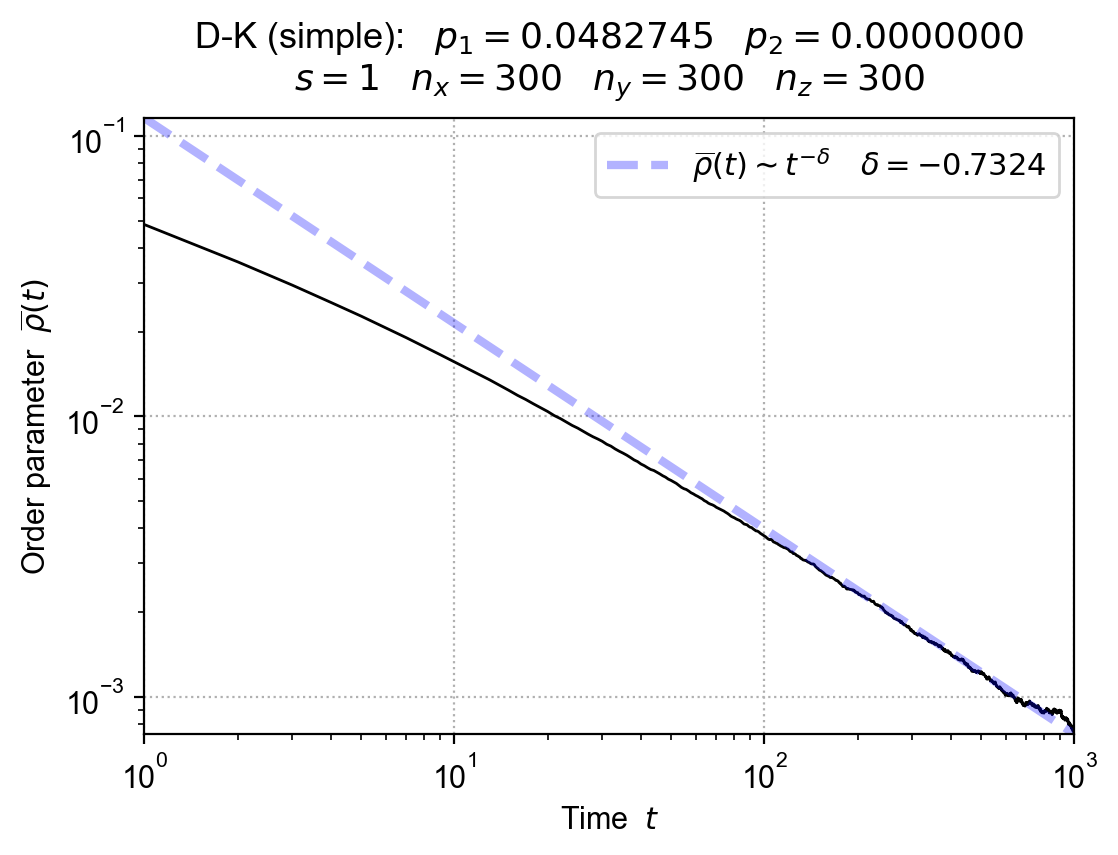

In [11]:
δ = 0.7324
match parameters.growth_scheme:
    case GrowthScheme.Staggered:
        scale = 0.116
    case GrowthScheme.Simple:
        scale = 0.116

name = make_name(parameters, "ρmean", None, )
print(name)
viz.lattice_statistic(
    name,
    make_title(parameters, None),
    parameters,
    tracking,
    choices=("time", "ρ_mean"),
    labels=(
        "Order parameter  $\\widebar{\\rho}(t)$", 
        "$\\widebar{\\rho}(t) \\sim t^{-\\delta}$",
        "${\\delta}$",
    ),
    exponent=-δ, 
    scale=scale,
    i_offset=1,
    do_ref_curve=True,
)
plt.show()

In [12]:
i_offset: int = parameters.n_iterations//50
t: NDArray = tracking["time"][i_offset:]
ρ_mean: NDArray = tracking["ρ_mean"][i_offset:]
(exponent, scale, r_value, p_value, std_err) \
    = linregress(np.log(t), np.log(ρ_mean))
print(f"t range: {t[0]}-{t[-1]}")
print(rf"Estimated t-decay exponent:  δ = {exponent:0.3f}")

t range: 20.0-1000.0
Estimated t-decay exponent:  δ = -0.682


<hr>

## Export

In [13]:
plots_dir: str = create_directories((os.path.curdir,"plots",), "dp3d")
export_plots(
    viz.fdict,
    plots_dir,
    "PNG",
    suffix="",
    dpi=150,
)

'././plots/dp3d'